In [1]:
import enum
from enum import Enum
from fractions import Fraction
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse

from gacha_model import COND_PROB_5_STAR, COND_PROB_6_STAR, PityModel
from plot_tools import draw_multi_cdf_fig, draw_multi_pmf_cdf_fig, draw_pmf_cdf_fig
from random_variable import FiniteDist

(<Figure size 3000x3000 with 2 Axes>,
 (<Axes: title={'center': '概率质量函数'}, ylabel='本抽概率'>,
  <Axes: title={'center': '累积分布函数'}, xlabel='寻访次数', ylabel='累积概率'>))

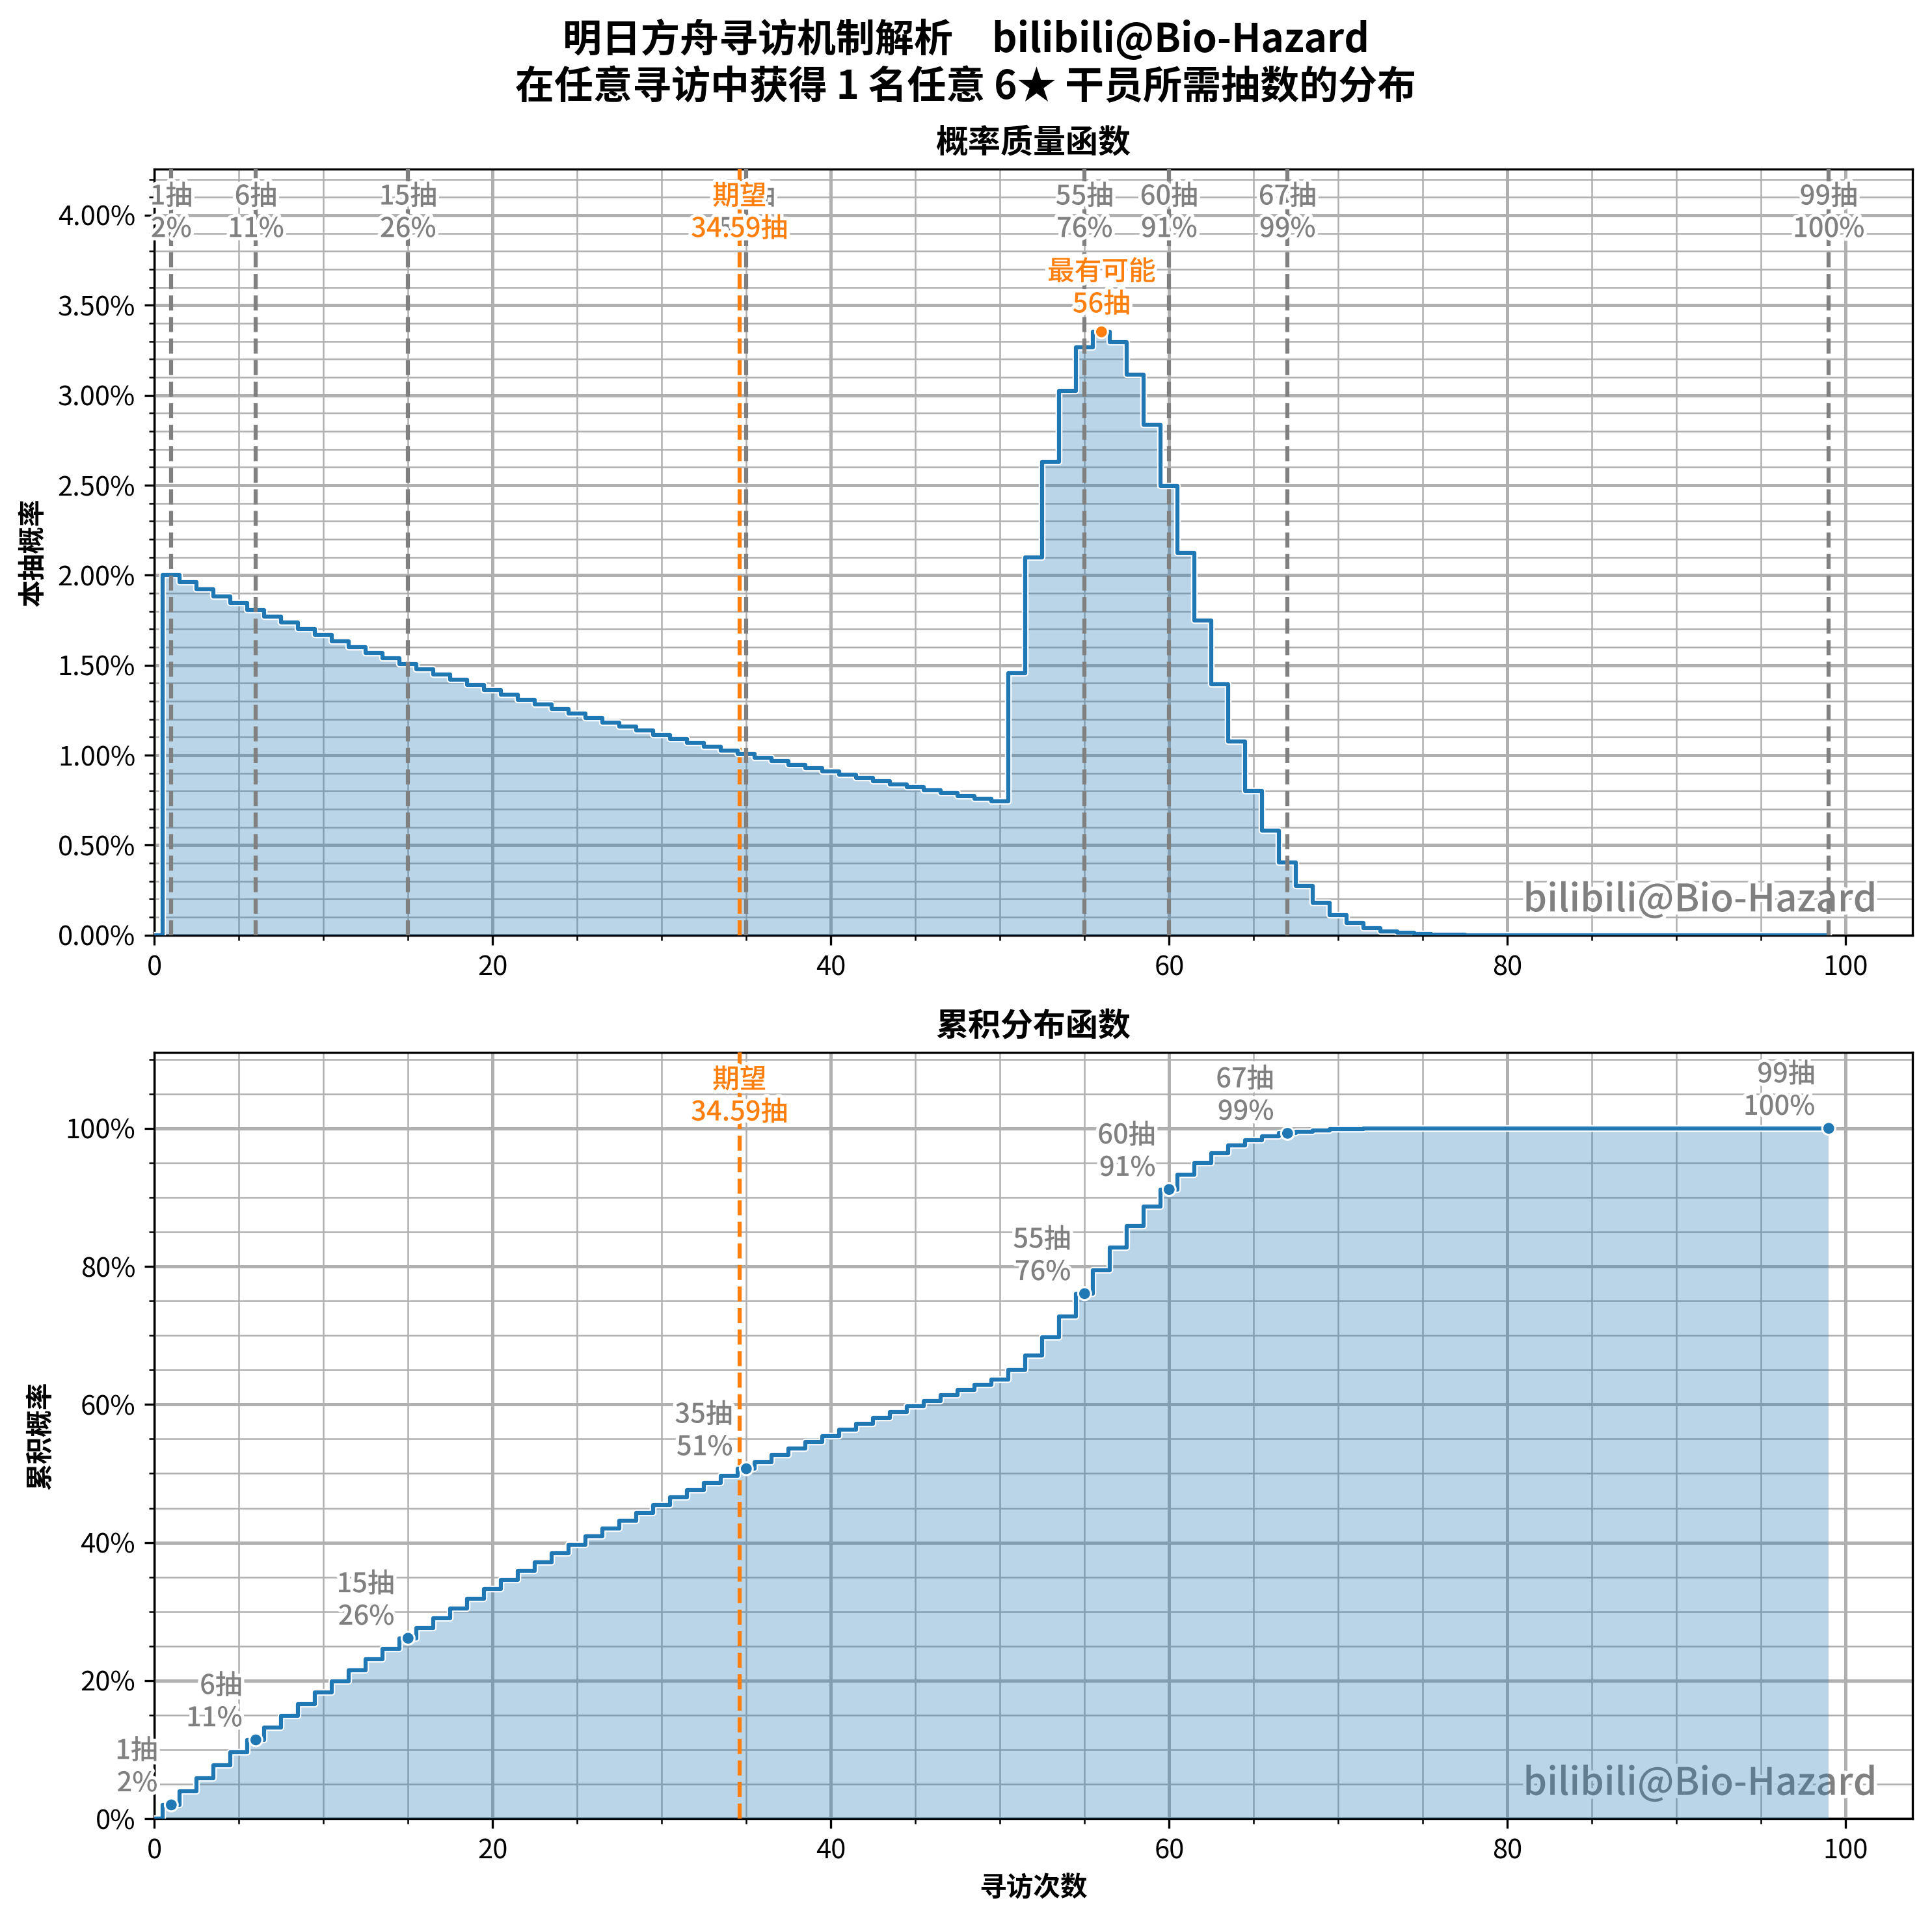

In [2]:
# 在任意寻访中获得若干名任意 6★ 干员所需抽数的分布

gacha_model = PityModel(COND_PROB_6_STAR)
dist_list: list[FiniteDist] = gacha_model(item_num=16)

quantile_poses = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 1]
draw_pmf_cdf_fig(dist_list[1], "在任意寻访中获得 1 名任意 6★ 干员所需抽数的分布", quantile_poses, drawstyle="steps-mid")

(<Figure size 3000x3000 with 2 Axes>,
 (<Axes: title={'center': '概率质量函数'}, ylabel='本抽概率'>,
  <Axes: title={'center': '累积分布函数'}, xlabel='寻访次数', ylabel='累积概率'>))

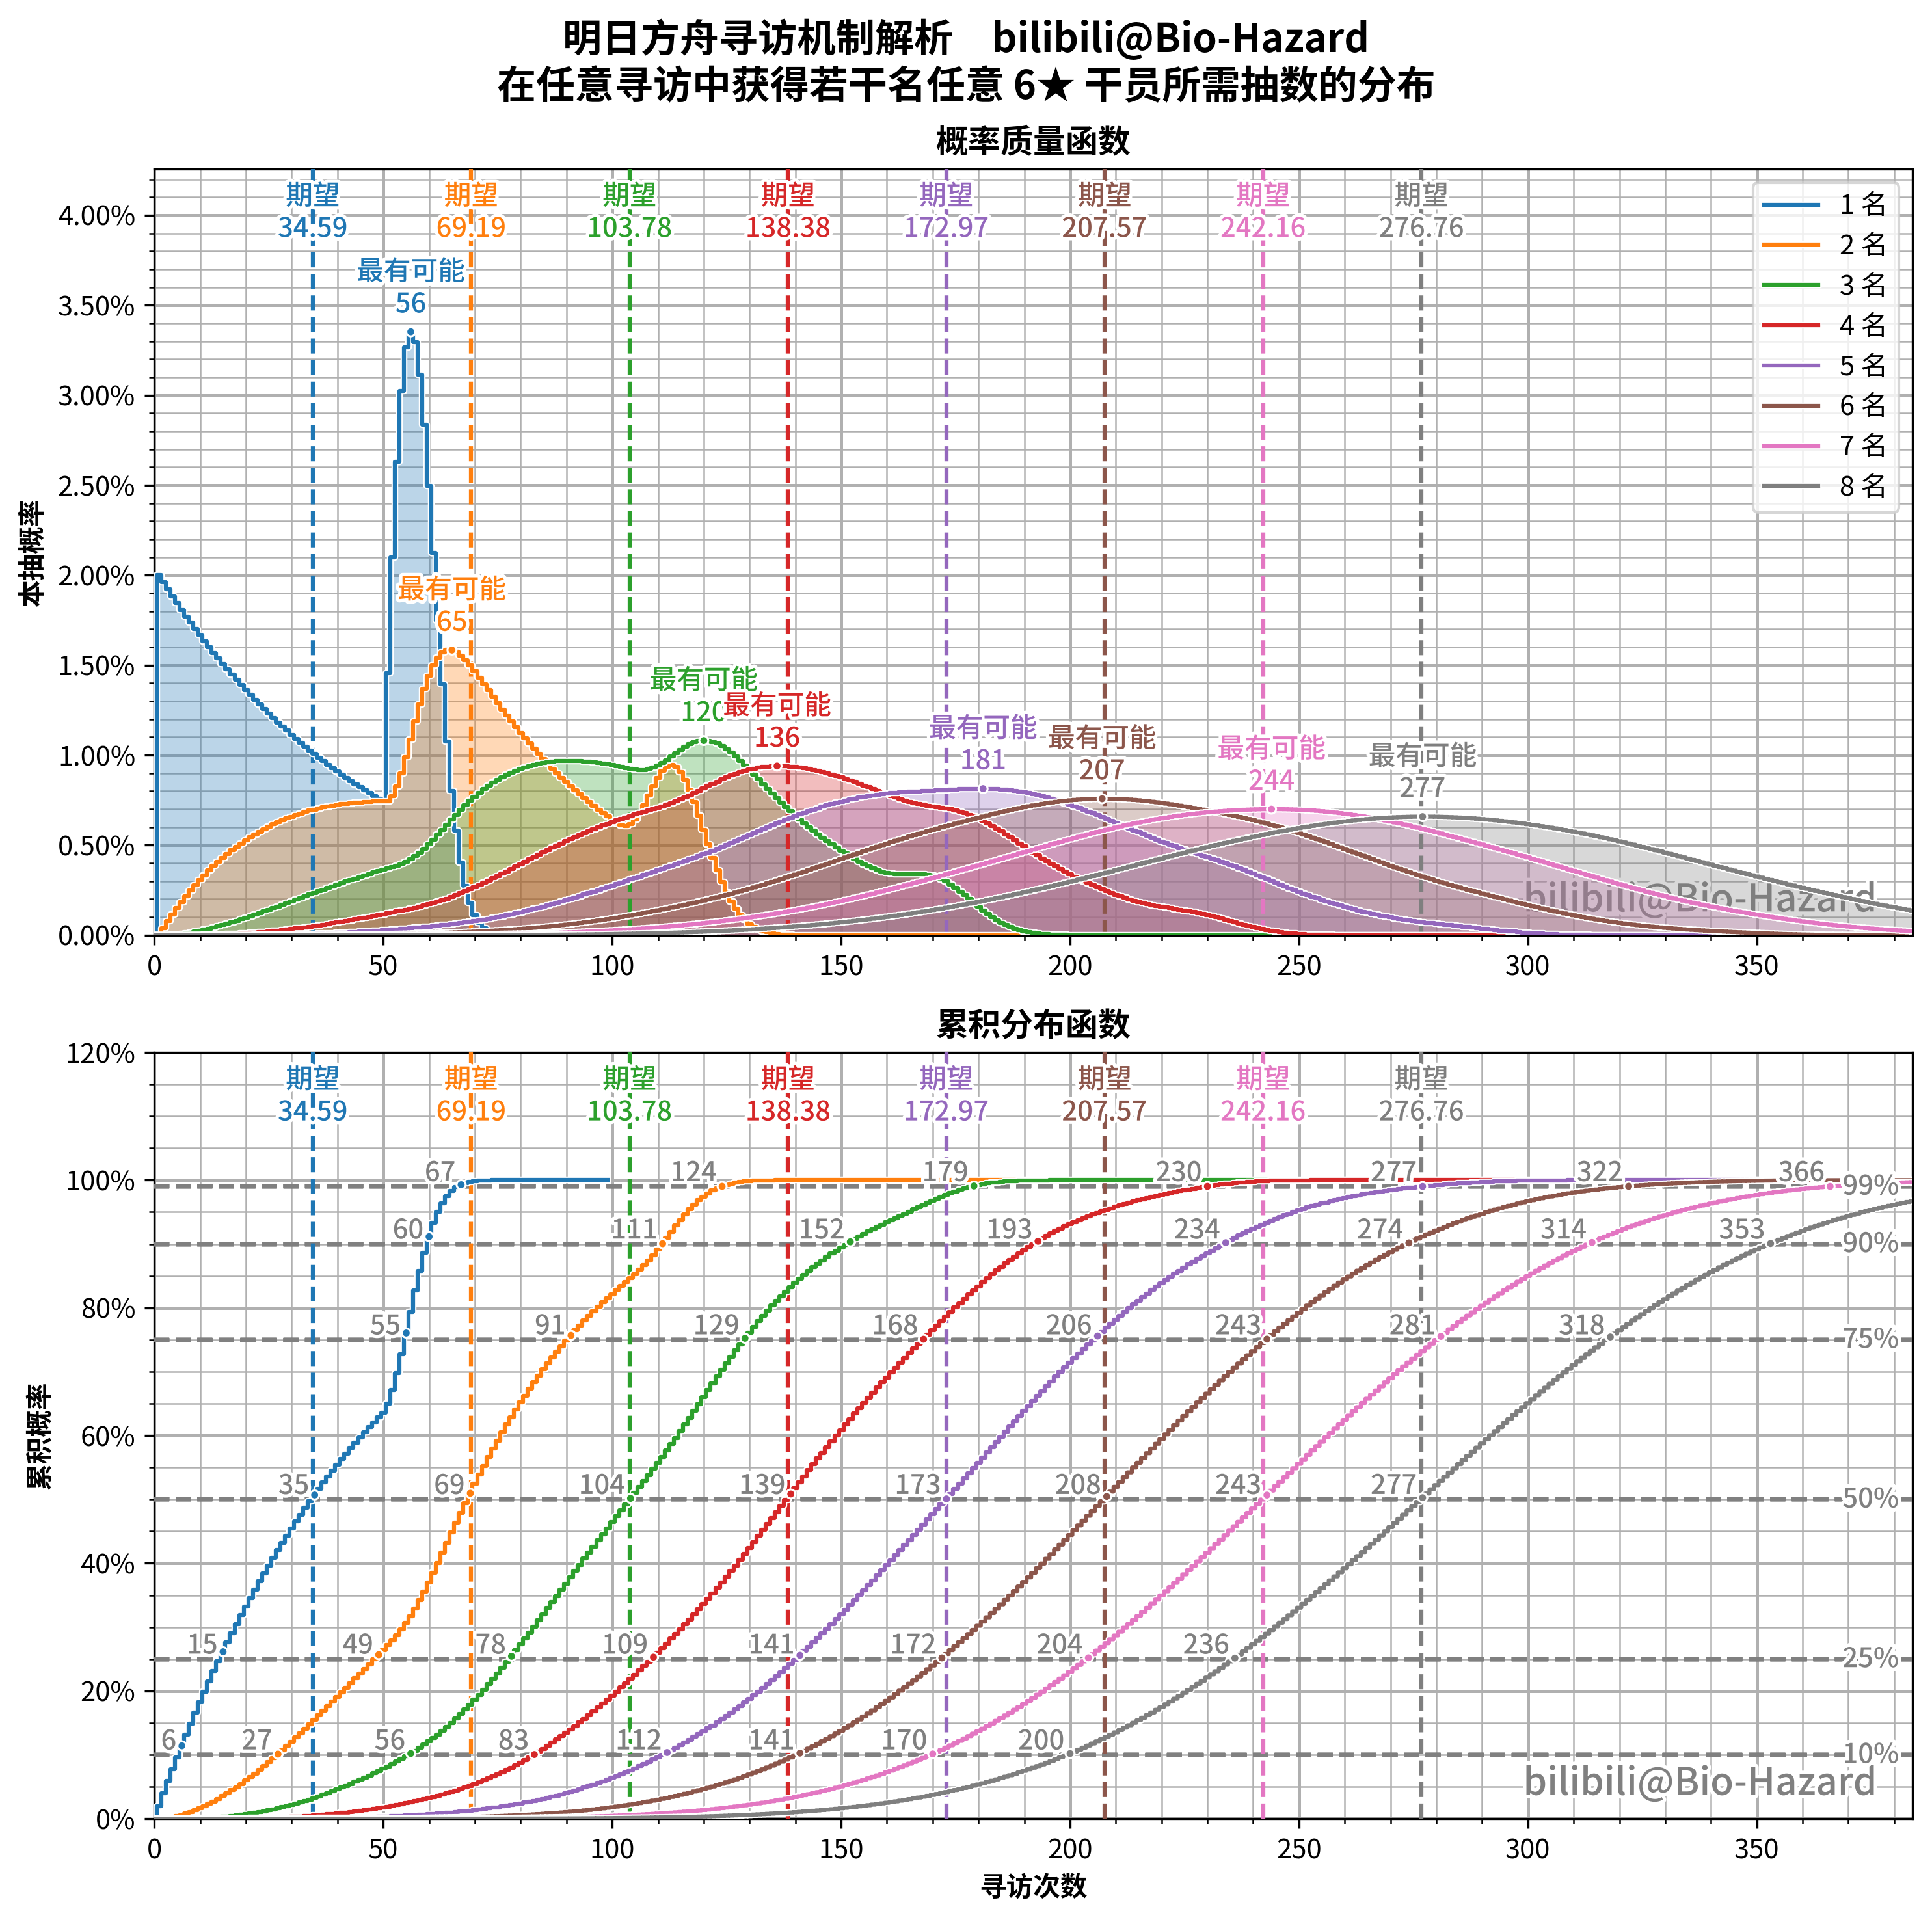

In [3]:
quantile_poses = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
draw_multi_pmf_cdf_fig(dist_list[1:], [f"{n} 名" for n in range(1, 8 + 1)], "在任意寻访中获得若干名任意 6★ 干员所需抽数的分布", quantile_poses, x_max=384, drawstyle="steps-mid")

(<Figure size 3000x3000 with 2 Axes>,
 (<Axes: title={'center': '概率质量函数'}, ylabel='本抽概率'>,
  <Axes: title={'center': '累积分布函数'}, xlabel='寻访次数', ylabel='累积概率'>))

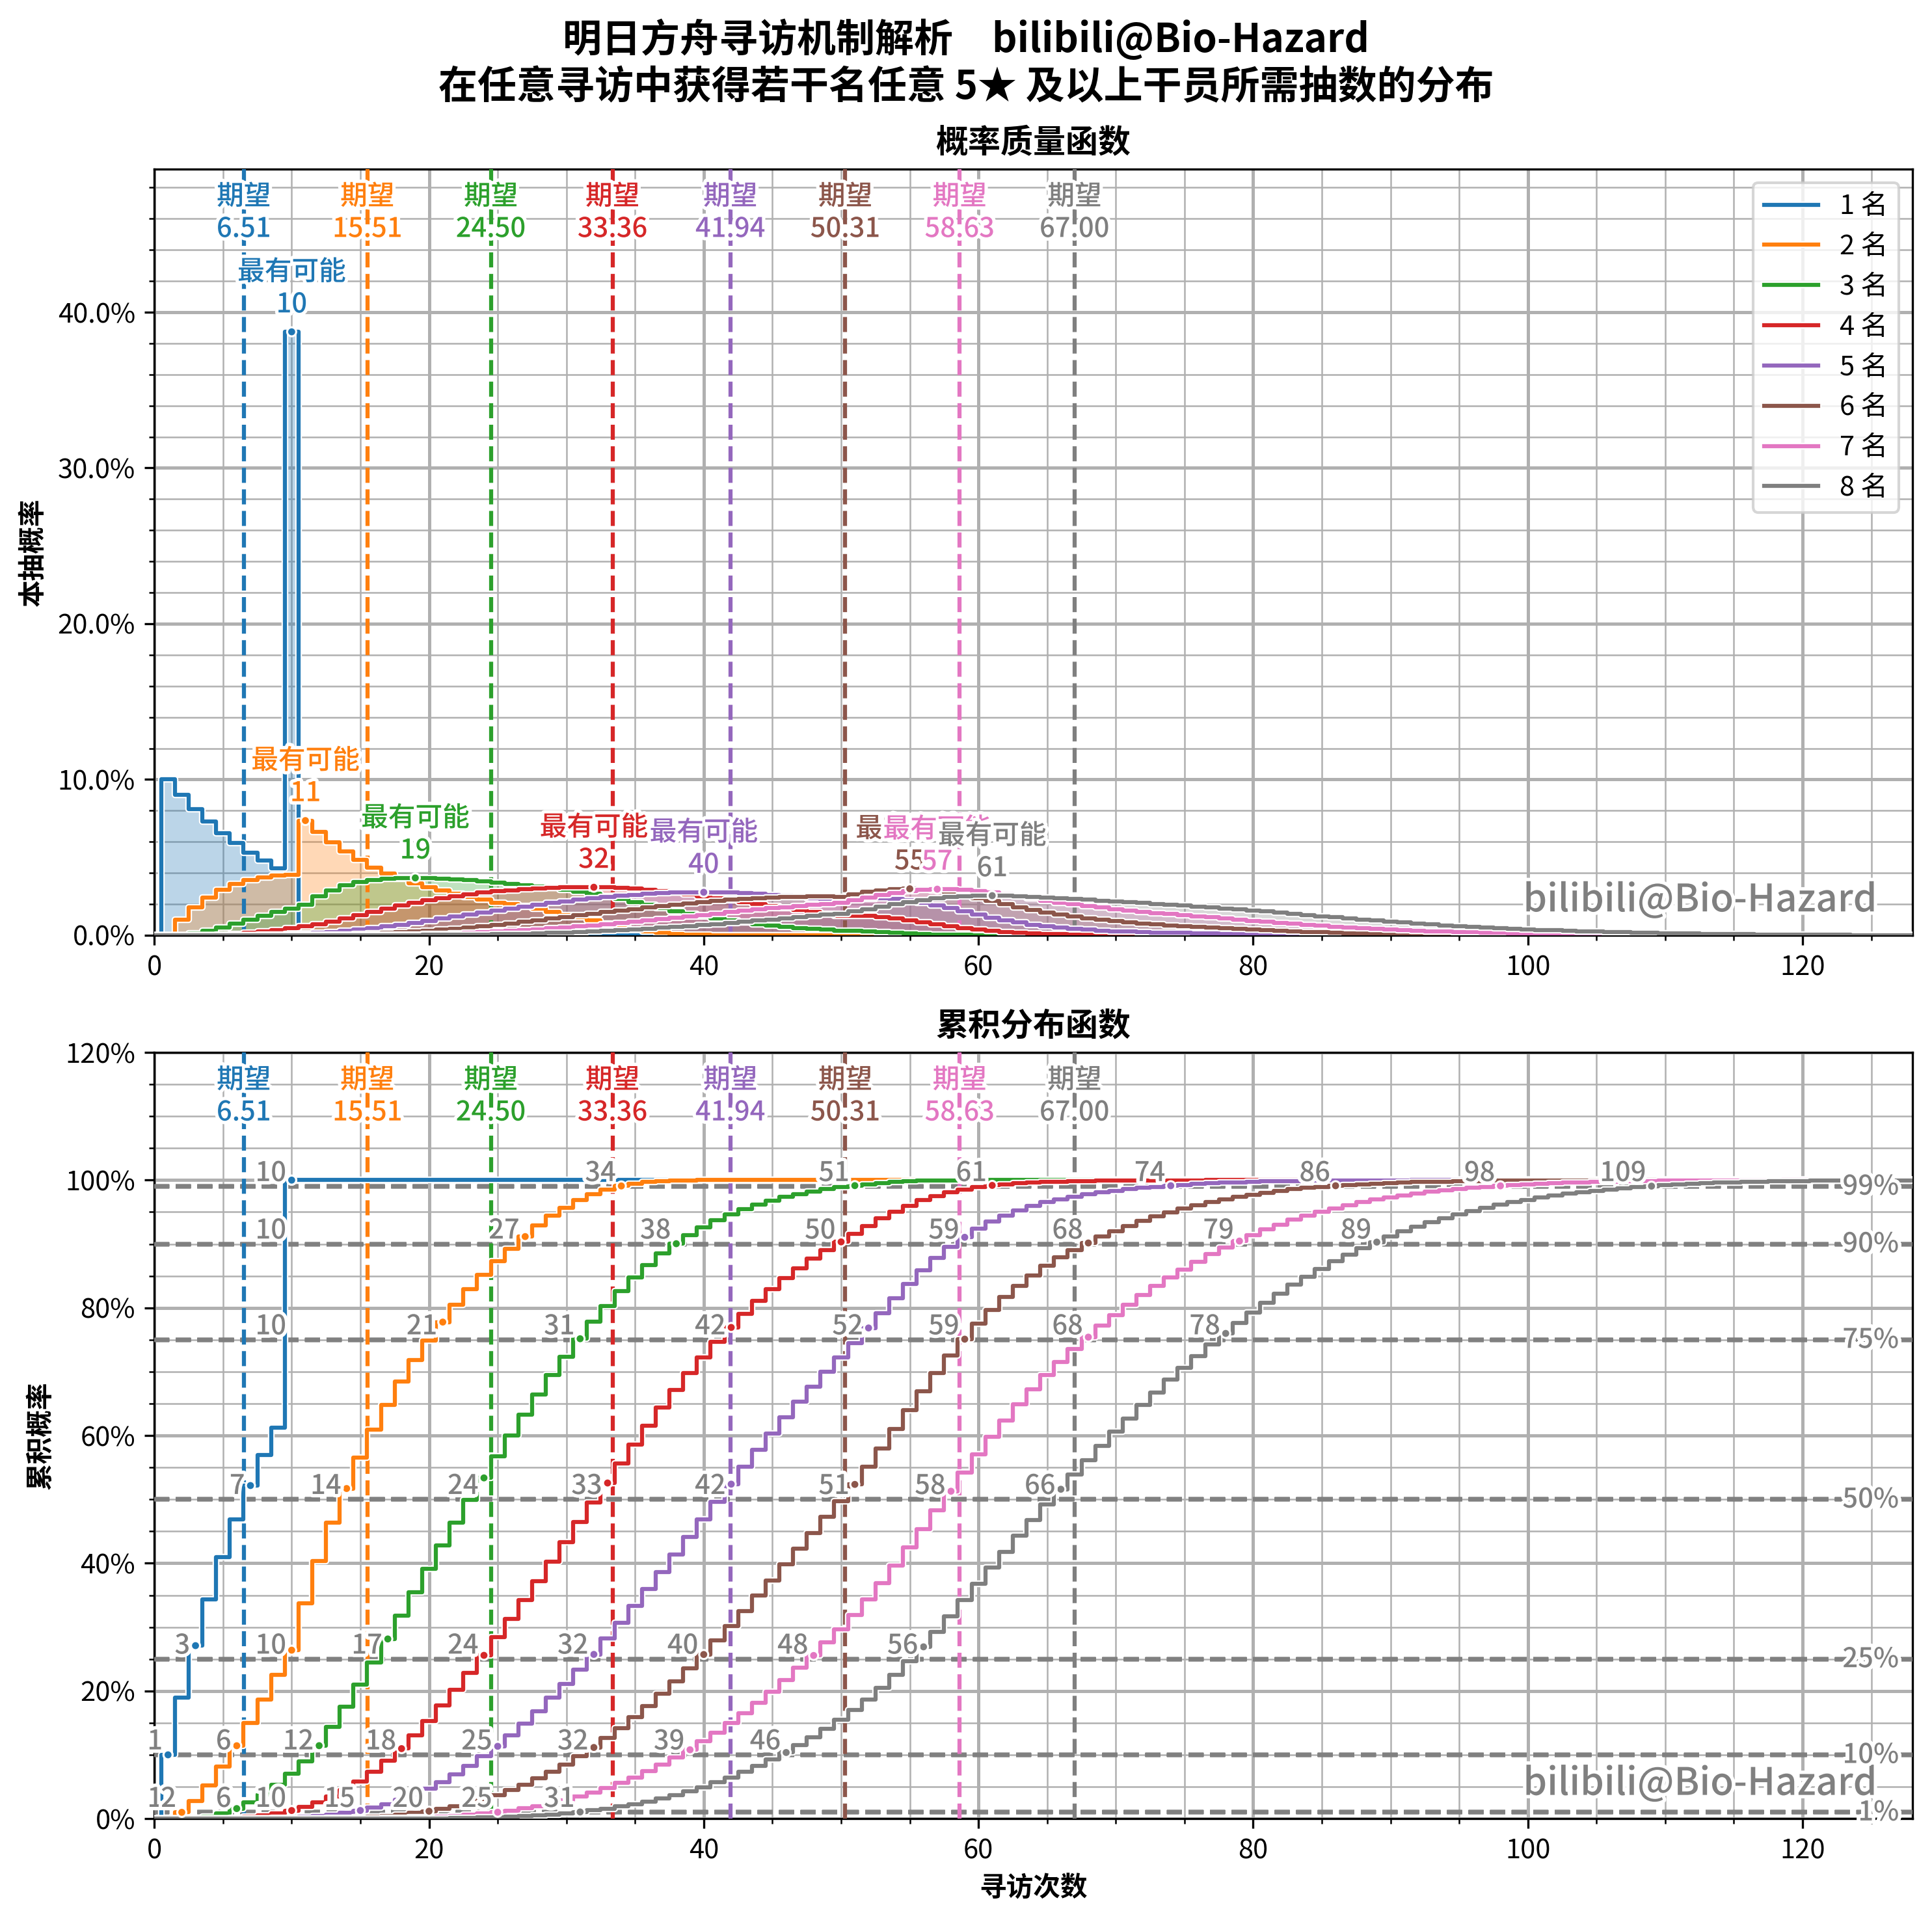

In [8]:
# 在任意寻访中获得若干名任意 5★ 及以上干员所需抽数的分布

type 状态类 = 过渡态类 | 吸收态类


class 过渡态类(NamedTuple):
    六星水位: int
    五星水位: int
    已获取五星及以上干员数量: int


class 吸收态类(Enum):
    pass


已获取五星及以上干员数量上限 = 8
迭代次数 = 1024


def 获取状态(*, 六星水位: int, 五星水位: int, 已获取五星及以上干员数量: int) -> 状态类:
    return 过渡态类(
        六星水位=六星水位,
        五星水位=五星水位,
        已获取五星及以上干员数量=min(已获取五星及以上干员数量, 已获取五星及以上干员数量上限),
    )


def 状态转移(起始状态: 状态类, *, 是第10抽: bool) -> list[tuple[状态类, float]]:
    转移概率列表: list[tuple[状态类, float]] = []

    if isinstance(起始状态, 吸收态类):
        转移概率列表.append((起始状态, 1))

    else:
        起始六星水位 = 起始状态.六星水位
        起始五星水位 = 起始状态.五星水位
        起始已获取五星及以上干员数量 = 起始状态.已获取五星及以上干员数量

        六星概率 = COND_PROB_6_STAR[起始六星水位]
        if 是第10抽 and 起始已获取五星及以上干员数量 == 0:
            五星概率 = 1 - 六星概率
        else:
            五星概率 = np.clip(COND_PROB_5_STAR[起始五星水位], 0, 1 - 六星概率)
        四星概率 = 1 - 六星概率 - 五星概率

        # 抽到六星干员
        转移概率列表.append((获取状态(六星水位=0, 五星水位=0, 已获取五星及以上干员数量=起始已获取五星及以上干员数量 + 1), 六星概率))

        # 抽到五星干员
        转移概率列表.append((获取状态(六星水位=起始六星水位 + 1, 五星水位=0, 已获取五星及以上干员数量=起始已获取五星及以上干员数量 + 1), 五星概率))

        # 抽到四星及以下干员
        转移概率列表.append((获取状态(六星水位=起始六星水位 + 1, 五星水位=起始五星水位 + 1, 已获取五星及以上干员数量=起始已获取五星及以上干员数量), 四星概率))

    转移概率列表 = [(目标状态, 概率) for 目标状态, 概率 in 转移概率列表 if 概率 > 0]
    assert np.isclose(sum(x[1] for x in 转移概率列表), 1)
    return 转移概率列表


状态列表: list[状态类] = []
状态列表.extend(过渡态类(六星水位=六星水位, 五星水位=五星水位, 已获取五星及以上干员数量=已获取五星及以上数量)
            for 六星水位 in range(0, 99, 1)
            for 五星水位 in range(0, 40, 1)
            for 已获取五星及以上数量 in range(0, 已获取五星及以上干员数量上限 + 1, 1))
状态数量: int = len(状态列表)
状态索引: dict[状态类, int] = {状态: i for i, 状态 in enumerate(状态列表)}


dok_状态转移矩阵_非第10抽 = scipy.sparse.dok_array((状态数量, 状态数量))
for 起始状态序号, 起始状态 in enumerate(状态列表):
    转移概率列表 = 状态转移(起始状态, 是第10抽=False)
    for 目标状态, 概率 in 转移概率列表:
        目标状态序号 = 状态索引[目标状态]
        dok_状态转移矩阵_非第10抽[起始状态序号, 目标状态序号] += 概率
状态转移矩阵_非第10抽 = dok_状态转移矩阵_非第10抽.tocsr()

dok_状态转移矩阵_第10抽 = scipy.sparse.dok_array((状态数量, 状态数量))
for 起始状态序号, 起始状态 in enumerate(状态列表):
    转移概率列表 = 状态转移(起始状态, 是第10抽=True)
    for 目标状态, 概率 in 转移概率列表:
        目标状态序号 = 状态索引[目标状态]
        dok_状态转移矩阵_第10抽[起始状态序号, 目标状态序号] += 概率
状态转移矩阵_第10抽 = dok_状态转移矩阵_第10抽.tocsr()


初始状态 = 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员数量=0)
当前状态分布 = np.zeros(状态数量)
当前状态分布[状态索引[初始状态]] = 1
历史状态分布 = np.zeros((迭代次数 + 1, 状态数量))
历史状态分布[0] = 当前状态分布

for i in range(迭代次数):
    状态转移矩阵 = 状态转移矩阵_第10抽 if i == 9 else 状态转移矩阵_非第10抽
    当前状态分布 = 当前状态分布 @ 状态转移矩阵
    历史状态分布[i + 1] = 当前状态分布


dists = []
for 已获取五星及以上数量 in range(0, 已获取五星及以上干员数量上限 + 1, 1):
    成功状态序号 = [状态序号 for 状态序号, 状态 in enumerate(状态列表) if isinstance(状态, 过渡态类) and 状态.已获取五星及以上干员数量 >= 已获取五星及以上数量]
    cdf = np.sum(历史状态分布[:, 成功状态序号], axis=1)
    pmf = np.clip(np.diff(cdf, prepend=0), 0, 1)
    dist = FiniteDist(pmf)
    dists.append(dist)

draw_multi_pmf_cdf_fig(dists=dists[1:],
                       labels=[f"{n} 名" for n in range(1, 已获取五星及以上干员数量上限 + 1, 1)],
                       title="在任意寻访中获得若干名任意 5★ 及以上干员所需抽数的分布",
                       quantile_poses=[0.01, 0.10, 0.25, 0.5, 0.75, 0.9, 0.99],
                       x_max=128,
                       drawstyle="steps-mid")

(<Figure size 3000x3000 with 2 Axes>,
 (<Axes: title={'center': '概率质量函数'}, ylabel='本抽概率'>,
  <Axes: title={'center': '累积分布函数'}, xlabel='寻访次数', ylabel='累积概率'>))

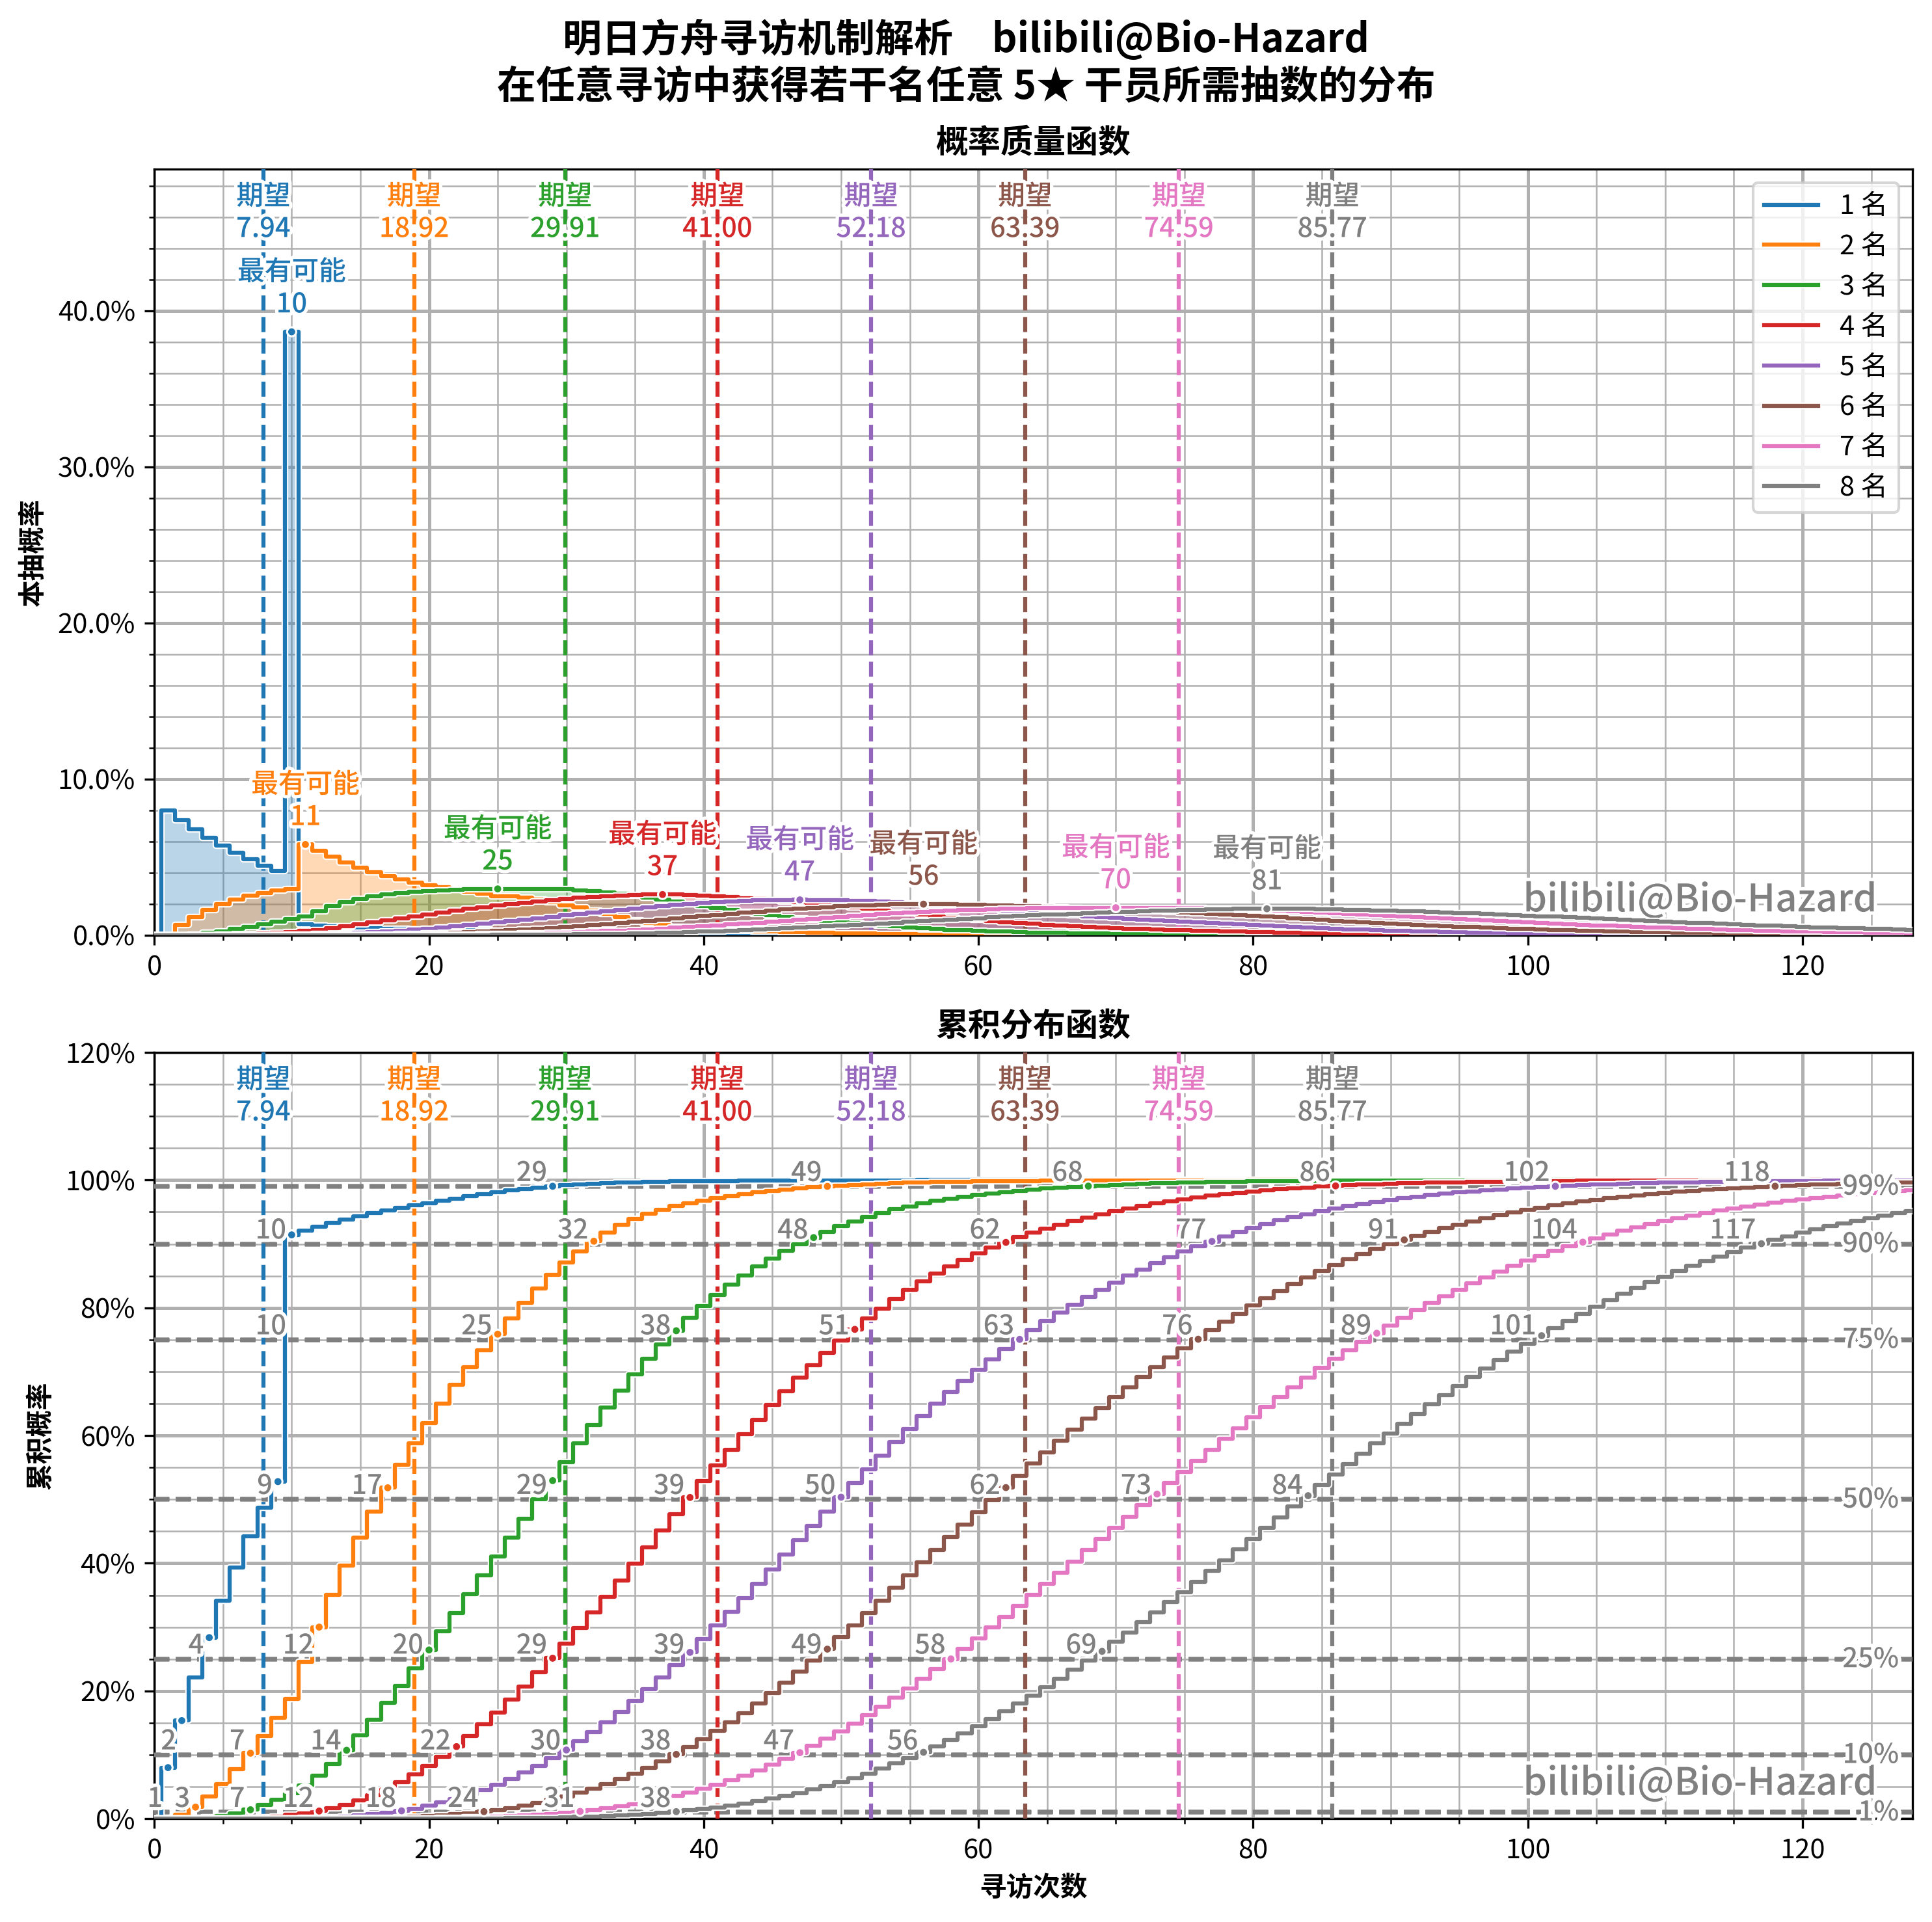

In [ ]:
# 在任意寻访中获得若干名任意 5★ 干员所需抽数的分布

type 状态类 = 过渡态类 | 吸收态类


class 过渡态类(NamedTuple):
    六星水位: int
    五星水位: int
    已获取五星及以上干员: bool
    已获取五星干员数量: int


class 吸收态类(Enum):
    pass


已获取五星干员数量上限 = 8
迭代次数 = 1024


def 获取状态(*, 六星水位: int, 五星水位: int, 已获取五星及以上干员: bool, 已获取五星干员数量: int) -> 状态类:
    return 过渡态类(
        六星水位=六星水位,
        五星水位=五星水位,
        已获取五星及以上干员=已获取五星及以上干员,
        已获取五星干员数量=min(已获取五星干员数量, 已获取五星干员数量上限),
    )


def 状态转移(起始状态: 状态类, *, 是第10抽: bool) -> list[tuple[状态类, float]]:
    转移概率列表: list[tuple[状态类, float]] = []

    if isinstance(起始状态, 吸收态类):
        转移概率列表.append((起始状态, 1))

    else:
        起始六星水位 = 起始状态.六星水位
        起始五星水位 = 起始状态.五星水位
        起始已获取五星及以上干员 = 起始状态.已获取五星及以上干员
        起始已获取五星干员数量 = 起始状态.已获取五星干员数量

        六星概率 = COND_PROB_6_STAR[起始六星水位]
        if 是第10抽 and not 起始已获取五星及以上干员:
            五星概率 = 1 - 六星概率
        else:
            五星概率 = np.clip(COND_PROB_5_STAR[起始五星水位], 0, 1 - 六星概率)
        四星概率 = 1 - 六星概率 - 五星概率

        # 抽到六星干员
        转移概率列表.append((获取状态(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=起始已获取五星干员数量), 六星概率))

        # 抽到五星干员
        转移概率列表.append((获取状态(六星水位=起始六星水位 + 1, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=起始已获取五星干员数量 + 1), 五星概率))

        # 抽到四星及以下干员
        转移概率列表.append((获取状态(六星水位=起始六星水位 + 1, 五星水位=起始五星水位 + 1, 已获取五星及以上干员=起始已获取五星及以上干员, 已获取五星干员数量=起始已获取五星干员数量), 四星概率))

    转移概率列表 = [(目标状态, 概率) for 目标状态, 概率 in 转移概率列表 if 概率 > 0]
    assert np.isclose(sum(x[1] for x in 转移概率列表), 1)
    return 转移概率列表


状态列表: list[状态类] = []
状态列表.extend(过渡态类(六星水位=六星水位, 五星水位=五星水位, 已获取五星及以上干员=已获取五星及以上干员, 已获取五星干员数量=已获取五星干员数量)
            for 六星水位 in range(0, 99, 1)
            for 五星水位 in range(0, 40, 1)
            for 已获取五星及以上干员 in (False, True)
            for 已获取五星干员数量 in range(0, 已获取五星干员数量上限 + 1, 1))
状态数量: int = len(状态列表)
状态索引: dict[状态类, int] = {状态: i for i, 状态 in enumerate(状态列表)}


dok_状态转移矩阵_非第10抽 = scipy.sparse.dok_array((状态数量, 状态数量))
for 起始状态序号, 起始状态 in enumerate(状态列表):
    转移概率列表 = 状态转移(起始状态, 是第10抽=False)
    for 目标状态, 概率 in 转移概率列表:
        目标状态序号 = 状态索引[目标状态]
        dok_状态转移矩阵_非第10抽[起始状态序号, 目标状态序号] += 概率
状态转移矩阵_非第10抽 = dok_状态转移矩阵_非第10抽.tocsr()

dok_状态转移矩阵_第10抽 = scipy.sparse.dok_array((状态数量, 状态数量))
for 起始状态序号, 起始状态 in enumerate(状态列表):
    转移概率列表 = 状态转移(起始状态, 是第10抽=True)
    for 目标状态, 概率 in 转移概率列表:
        目标状态序号 = 状态索引[目标状态]
        dok_状态转移矩阵_第10抽[起始状态序号, 目标状态序号] += 概率
状态转移矩阵_第10抽 = dok_状态转移矩阵_第10抽.tocsr()


初始状态 = 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=False, 已获取五星干员数量=0)
当前状态分布 = np.zeros(状态数量)
当前状态分布[状态索引[初始状态]] = 1
历史状态分布 = np.zeros((迭代次数 + 1, 状态数量))
历史状态分布[0] = 当前状态分布

for i in range(迭代次数):
    状态转移矩阵 = 状态转移矩阵_第10抽 if i == 9 else 状态转移矩阵_非第10抽
    当前状态分布 = 当前状态分布 @ 状态转移矩阵
    历史状态分布[i + 1] = 当前状态分布


dists = []
for 已获取五星干员数量 in range(0, 已获取五星干员数量上限 + 1, 1):
    成功状态序号 = [状态序号 for 状态序号, 状态 in enumerate(状态列表) if isinstance(状态, 过渡态类) and 状态.已获取五星干员数量 >= 已获取五星干员数量]
    cdf = np.sum(历史状态分布[:, 成功状态序号], axis=1)
    pmf = np.clip(np.diff(cdf, prepend=0), 0, 1)
    dist = FiniteDist(pmf)
    dists.append(dist)

draw_multi_pmf_cdf_fig(dists=dists[1:],
                       labels=[f"{n} 名" for n in range(1, 已获取五星干员数量上限 + 1, 1)],
                       title="在任意寻访中获得若干名任意 5★ 干员所需抽数的分布",
                       quantile_poses=[0.01, 0.10, 0.25, 0.5, 0.75, 0.9, 0.99],
                       x_max=128,
                       drawstyle="steps-mid")

In [ ]:
def 打印状态分布(状态分布向量):
    for 状态序号, (状态, 概率) in enumerate(zip(状态列表, 状态分布向量)):
        if 概率 != 0:
            print(f"状态 {状态序号}: {状态}, 概率: {概率:.4%}")
打印状态分布(历史状态分布[10])

状态 9: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=0), 概率: 0.9443%
状态 10: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=1), 概率: 0.7390%
状态 11: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=2), 概率: 0.2571%
状态 12: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=3), 概率: 0.0522%
状态 13: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=4), 概率: 0.0068%
状态 14: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=5), 概率: 0.0006%
状态 15: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=6), 概率: 0.0000%
状态 16: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=7), 概率: 0.0000%
状态 17: 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=8), 概率: 0.0000%
状态 730: 过渡态类(六星水位=1, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=1), 概率: 0.0821%
状态 731: 过渡态类(六星水位=1, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=2), 概率: 0.0571%
状态 732: 过渡态类(六星水位=1, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=3), 概率: 0.0174%
状态 733: 过渡态类(六星水位=1, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=4), 概率: 0.0030%
状态 734: 过渡态类(六星水位=1, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=5), 概率: 0.0003%
状态

In [ ]:
# 在联动寻访中获得若干名任意 5★ 干员所需抽数的分布

type 状态类 = 过渡态类 | 吸收态类


class 过渡态类(NamedTuple):
    六星水位: int
    五星水位: int
    已获取五星及以上干员: bool
    已获取五星干员数量: int


class 吸收态类(Enum):
    pass


已获取五星干员数量上限 = 8
迭代次数 = 1024


def 获取状态(*, 六星水位: int, 五星水位: int, 已获取五星及以上干员: bool, 已获取五星干员数量: int) -> 状态类:
    return 过渡态类(
        六星水位=六星水位,
        五星水位=五星水位,
        已获取五星及以上干员=已获取五星及以上干员,
        已获取五星干员数量=min(已获取五星干员数量, 已获取五星干员数量上限),
    )


def 状态转移(起始状态: 状态类, *, 是第10抽: bool) -> list[tuple[状态类, float]]:
    转移概率列表: list[tuple[状态类, float]] = []

    if isinstance(起始状态, 吸收态类):
        转移概率列表.append((起始状态, 1))

    else:
        起始六星水位 = 起始状态.六星水位
        起始五星水位 = 起始状态.五星水位
        起始已获取五星及以上干员 = 起始状态.已获取五星及以上干员
        起始已获取五星干员数量 = 起始状态.已获取五星干员数量

        六星概率 = COND_PROB_6_STAR[起始六星水位]
        if 是第10抽 and not 起始已获取五星及以上干员:
            五星概率 = 1 - 六星概率
        else:
            五星概率 = np.clip(COND_PROB_5_STAR[起始五星水位], 0, 1 - 六星概率)
        四星概率 = 1 - 六星概率 - 五星概率

        # 抽到六星干员
        转移概率列表.append((获取状态(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=起始已获取五星干员数量), 六星概率))

        # 抽到五星干员
        转移概率列表.append((获取状态(六星水位=起始六星水位 + 1, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=起始已获取五星干员数量 + 1), 五星概率))

        # 抽到四星及以下干员
        转移概率列表.append((获取状态(六星水位=起始六星水位 + 1, 五星水位=起始五星水位 + 1, 已获取五星及以上干员=起始已获取五星及以上干员, 已获取五星干员数量=起始已获取五星干员数量), 四星概率))

    转移概率列表 = [(目标状态, 概率) for 目标状态, 概率 in 转移概率列表 if 概率 > 0]
    assert np.isclose(sum(x[1] for x in 转移概率列表), 1)
    return 转移概率列表


状态列表: list[状态类] = []
状态列表.extend(过渡态类(六星水位=六星水位, 五星水位=五星水位, 已获取五星及以上干员=已获取五星及以上干员, 已获取五星干员数量=已获取五星干员数量)
            for 六星水位 in range(0, 99, 1)
            for 五星水位 in range(0, 40, 1)
            for 已获取五星及以上干员 in (False, True)
            for 已获取五星干员数量 in range(0, 已获取五星干员数量上限 + 1, 1))
状态数量: int = len(状态列表)
状态索引: dict[状态类, int] = {状态: i for i, 状态 in enumerate(状态列表)}


dok_状态转移矩阵_非第10抽 = scipy.sparse.dok_array((状态数量, 状态数量))
for 起始状态序号, 起始状态 in enumerate(状态列表):
    转移概率列表 = 状态转移(起始状态, 是第10抽=False)
    for 目标状态, 概率 in 转移概率列表:
        目标状态序号 = 状态索引[目标状态]
        dok_状态转移矩阵_非第10抽[起始状态序号, 目标状态序号] += 概率
状态转移矩阵_非第10抽 = dok_状态转移矩阵_非第10抽.tocsr()

dok_状态转移矩阵_第10抽 = scipy.sparse.dok_array((状态数量, 状态数量))
for 起始状态序号, 起始状态 in enumerate(状态列表):
    转移概率列表 = 状态转移(起始状态, 是第10抽=True)
    for 目标状态, 概率 in 转移概率列表:
        目标状态序号 = 状态索引[目标状态]
        dok_状态转移矩阵_第10抽[起始状态序号, 目标状态序号] += 概率
状态转移矩阵_第10抽 = dok_状态转移矩阵_第10抽.tocsr()


初始状态 = 过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=False, 已获取五星干员数量=0)
当前状态分布 = np.zeros(状态数量)
当前状态分布[状态索引[初始状态]] = 1
历史状态分布 = np.zeros((迭代次数 + 1, 状态数量))
历史状态分布[0] = 当前状态分布

for i in range(迭代次数):
    状态转移矩阵 = 状态转移矩阵_第10抽 if i == 9 else 状态转移矩阵_非第10抽
    当前状态分布 = 当前状态分布 @ 状态转移矩阵
    历史状态分布[i + 1] = 当前状态分布


dists = []
for 已获取五星干员数量 in range(0, 已获取五星干员数量上限 + 1, 1):
    成功状态序号 = [状态序号 for 状态序号, 状态 in enumerate(状态列表) if isinstance(状态, 过渡态类) and 状态.已获取五星干员数量 >= 已获取五星干员数量]
    cdf = np.sum(历史状态分布[:, 成功状态序号], axis=1)
    pmf = np.clip(np.diff(cdf, prepend=0), 0, 1)
    dist = FiniteDist(pmf)
    dists.append(dist)

draw_multi_pmf_cdf_fig(dists=dists[1:],
                       labels=[f"{n} 名" for n in range(1, 已获取五星干员数量上限 + 1, 1)],
                       title="在任意寻访中获得若干名任意 5★ 干员所需抽数的分布",
                       quantile_poses=[0.01, 0.10, 0.25, 0.5, 0.75, 0.9, 0.99],
                       x_max=128,
                       drawstyle="steps-mid")

[(过渡态类(六星水位=0, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=0), np.float64(0.02)),
 (过渡态类(六星水位=10, 五星水位=0, 已获取五星及以上干员=True, 已获取五星干员数量=1), np.float64(0.98))]